In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

from dotenv import load_dotenv
from mpl_chord_diagram import chord_diagram

load_dotenv()

True

In [12]:
LANGUAGE = "en"
ZONE = "GUY+Georgetown"

In [13]:
data_path = Path(os.environ["DATA_PATH"])
ghsl_path = Path(os.environ["GHSL_PATH"])
out_path = data_path / "generated"

figure_path: Path = Path("./fig") / LANGUAGE / ZONE
figure_path.mkdir(parents=True, exist_ok=True)

In [14]:
_color_map_base = {
    "croplands": "#B8860B",
    "flooded": "#4169E1",
    "forests_primary": "#006400",
    "forests_secondary": "#228B22",
    "grasslands": "#90EE90",
    "other": "#9932CC",
    "pastures": "#FFD700",
    "settlements": "#808080",
    "shrublands": "#FFA07A",
    "wetlands": "#40E0D0",
}

if LANGUAGE == "en":
    COLUMN_NAME_MAP = {
        "croplands": "Croplands",
        "flooded": "Flooded",
        "forests_primary": "Primary forests",
        "forests_secondary": "Secondary forests",
        "grasslands": "Grasslands",
        "other": "Other",
        "pastures": "Pastures",
        "settlements": "Settlements",
        "shrublands": "Shrublands",
        "wetlands": "Wetlands"
    }
elif LANGUAGE == "es":
    COLUMN_NAME_MAP = {
        "croplands": "Cultivos",
        "flooded": "Inundado",
        "forests_primary": "Bosques primarios",
        "forests_secondary": "Bosques secundarios",
        "grasslands": "Pastizales",
        "other": "Otro",
        "pastures": "Pastizales\np/ganado",
        "settlements": "Asentamientos",
        "shrublands": "Matorrales",
        "wetlands": "Humedales"
    }
else:
    raise ValueError("Language not supported")


COLUMN_COLOR_MAP = {COLUMN_NAME_MAP[key]: _color_map_base[key] for key in COLUMN_NAME_MAP.keys()}
COLUMN_COLOR_MAP["Total"] = "#000000"

# Area

In [15]:
df_area = (
    pd.read_csv(out_path / "small" / "area" / "table_merged" / f"{ZONE}.csv")
    .set_index("label")
    .T
    .reset_index(names="year")
    .assign(year=lambda df: (df["year"].astype(int) + 2000))
    .query("2000 <= year <= 2020")
    .assign(year=lambda df: df["year"].astype(str))
    .set_index("year")
    .divide(100)
    .rename(columns=COLUMN_NAME_MAP)
)

masked = (df_area.div(df_area.sum(axis=1), axis=0) < 0.01).all(axis=0)
masked_cols = masked[~masked].index

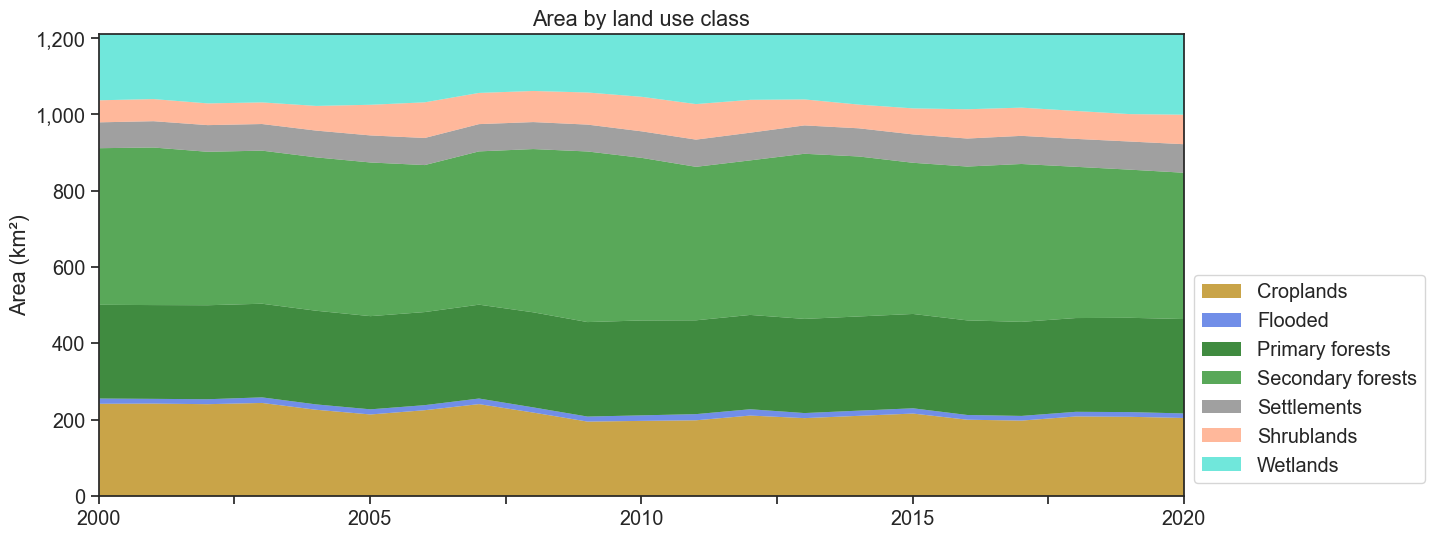

In [16]:
sns.set_theme(style="ticks", font_scale=1.3)

fig, ax = plt.subplots(figsize=(14, 6))
df_area[masked_cols].plot.area(ax=ax, color=COLUMN_COLOR_MAP, alpha=0.75, lw=0)
ax.legend(bbox_to_anchor=(1, 0.5))

ax.set_xlim(0, 20)
ax.set_ylim(0, df_area.sum(axis=1).max() * 0.97)

if LANGUAGE == "en":
    ax.set_ylabel("Area (km²)")
elif LANGUAGE == "es":
    ax.set_ylabel("Área (km²)")
else:
    raise ValueError("Language not supported")

ax.set_xlabel(None)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

if LANGUAGE == "en":
    ax.set_title("Area by land use class")
elif LANGUAGE == "es":
    ax.set_title("Área por clase de uso de suelo")
else:
    raise ValueError("Language not supported")

fig.savefig(figure_path / "area.jpg", bbox_inches="tight", dpi=200)

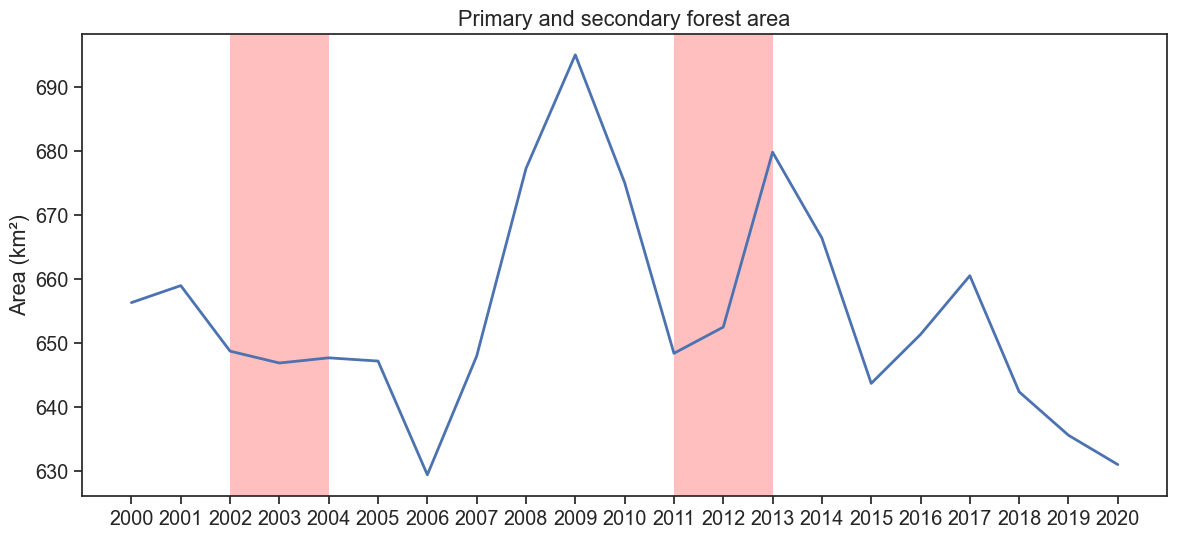

In [17]:
sns.set_theme(style="ticks", font_scale=1.3)

if LANGUAGE == "en":
    wanted_cols = ["Primary forests", "Secondary forests"]
elif LANGUAGE == "es":
    wanted_cols = ["Bosques primarios", "Bosques secundarios"]
else:
    raise ValueError("Language not supported")

df_temp = df_area.filter(wanted_cols, axis=1).filter([str(year) for year in range(2000, 2021)], axis=0).sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(df_temp, ax=ax, lw=2, c="C0")
ax.axvspan("2002", "2004", color="red", alpha=0.25, ec="none")
ax.axvspan("2011", "2013", color="red", alpha=0.25, ec="none")

if LANGUAGE == "en":
    ax.set_ylabel("Area (km²)")
    ax.set_title("Primary and secondary forest area")
elif LANGUAGE == "es":
    ax.set_ylabel("Área (km²)")
    ax.set_title("Área de bosques primarios y secundarios")
else:
    raise ValueError("Language not supported")

fig.savefig(figure_path / "area_forest.jpg", bbox_inches="tight", dpi=200)

# Area transitions

## Circle

In [18]:
pivot = (
    pd.read_csv(out_path / "small" / "transition" / "table_fixed_extra" / "2000_2020" / f"{ZONE}.csv")
    .set_index("start")
    .sort_index(axis=0).sort_index(axis=1)
)

mask = (pivot.sum(axis=0) > 10 * 1e6) & (pivot.sum(axis=1) > 10 * 1e6)
wanted_idx = mask[mask].index

pivot = pivot.filter(wanted_idx, axis=0).filter(wanted_idx, axis=1)

names = [COLUMN_NAME_MAP[c] for c in pivot.index]

mat = pivot.to_numpy()
np.fill_diagonal(mat, 0)

if ZONE == "MEX+Monterrey":
    rotate_names = [False, False, False, True, True, True, False, False]
elif ZONE == "PER+Maynas":
    rotate_names = [True, False, False, True, True, True, False]
else:
    rotate_names = [False] * len(names)

fig, ax = plt.subplots(figsize=(8, 8))
diag = chord_diagram(
    mat,
    ax=ax,
    names=names,
    directed=True,
    rotate_names=rotate_names,
    colors=[COLUMN_COLOR_MAP[c] for c in names],
    fontsize=16,
)
fig.savefig(figure_path / "chord_bidirectional.jpg", bbox_inches="tight", dpi=200)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\lain\\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\\afolu_resources\\generated\\small\\transition\\table_fixed_extra\\2000_2020\\GUY+Georgetown.csv'

# Emissions

In [20]:
df_cube = (
    pd.read_csv(out_path / "small" / "transition" / "cube" / f"{ZONE}.csv")
    .melt(id_vars="time_period")
    .assign(
        start=lambda df: df["variable"].str.split("_to_").str[0],
        end=lambda df: df["variable"].str.split("_to_").str[1],
    )
    .drop(columns=["variable"])
    .pivot_table(index="start", columns="end", values="value")
    .fillna(0)
)
df_cube

end,croplands,flooded,forests_mangroves,forests_primary,forests_secondary,grasslands,other,pastures,settlements,shrublands,wetlands
start,,,,,,,,,,,
pij_lndu_croplands,0.923688,0.000127,0.000012,0.000000,0.049711,9.426137e-04,0.000000,0.0,0.004884,0.018626,0.002010
pij_lndu_flooded,0.001247,0.883433,0.000229,0.000000,0.003111,3.194146e-04,0.000186,0.0,0.000827,0.002948,0.107699
pij_lndu_forests_mangroves,0.001525,0.002926,0.917388,0.000000,0.029841,3.116632e-05,0.000706,0.0,0.002314,0.002111,0.043159
pij_lndu_forests_primary,0.000007,0.000004,0.000030,0.989642,0.000000,3.266994e-07,0.000000,0.0,0.000000,0.000009,0.010308
pij_lndu_forests_secondary,0.025625,0.000072,0.000084,0.000000,0.902178,4.312283e-04,0.000000,0.0,0.002114,0.015335,0.054160
pij_lndu_grasslands,0.012466,0.000232,0.000000,0.000000,0.024057,8.932307e-01,0.000004,0.0,0.023064,0.044255,0.002690
pij_lndu_other,0.000117,0.005698,0.002603,0.000000,0.000000,0.000000e+00,0.971800,0.0,0.001288,0.000000,0.018495
pij_lndu_pastures,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.0,0.000000,0.000000,0.000000
pij_lndu_settlements,0.012329,0.000140,0.000040,0.000000,0.010957,2.552008e-03,0.000008,0.0,0.956006,0.017703,0.000264


In [24]:
df_out = pd.read_csv(out_path / "small" / "emissions" / f"{ZONE}.csv").drop(columns=["Unnamed: 0"]).query("time_period < 21")
df_out

,time_period,frac_area_cropland_calculated_bevs_and_spices,frac_area_cropland_calculated_cereals,frac_area_cropland_calculated_fibers,frac_area_cropland_calculated_fruits,frac_area_cropland_calculated_herbs_and_other_perennial_crops,frac_area_cropland_calculated_nuts,frac_area_cropland_calculated_other_annual,frac_area_cropland_calculated_other_woody_perennial,frac_area_cropland_calculated_pulses,...,emission_co2e_co2_soil_lime_use,emission_co2e_co2_soil_urea_use,demand_soil_lime_kt,demand_soil_urea_kt,emission_co2e_subsector_total_agrc,emission_co2e_subsector_total_frst,emission_co2e_subsector_total_lndu,emission_co2e_subsector_total_lsmm,emission_co2e_subsector_total_lvst,emission_co2e_subsector_total_soil
0,0,0.0,0.163562,0.030331,0.000036,0.035202,0.002985,0.513194,0.0,0.000159,...,0.011205,1.392307,22.000000,1898.600000,0.017083,-0.127243,0.678423,0.284571,1.240654,17.785520
1,1,0.0,0.163562,0.030331,0.000036,0.035202,0.002985,0.513194,0.0,0.000159,...,0.011227,1.531076,22.043864,2087.830887,0.017265,-0.128329,0.802162,0.283665,1.240709,18.084017
2,2,0.0,0.163562,0.030331,0.000036,0.035202,0.002985,0.513194,0.0,0.000159,...,0.011159,1.443657,21.910431,1968.623080,0.018249,-0.125997,0.710353,0.284538,1.240693,17.831191
3,3,0.0,0.163562,0.030331,0.000036,0.035202,0.002985,0.513194,0.0,0.000159,...,0.011316,1.505250,22.218200,2052.613340,0.017341,-0.125924,0.641382,0.286039,1.240620,18.162362
4,4,0.0,0.163562,0.030331,0.000036,0.035202,0.002985,0.513194,0.0,0.000159,...,0.010494,1.322290,20.603891,1803.123069,0.015937,-0.126363,0.599851,0.287343,1.240626,16.730002
5,5,0.0,0.163562,0.030331,0.000036,0.035202,0.002985,0.513194,0.0,0.000159,...,0.009931,1.250069,19.498759,1704.639817,0.015185,-0.126497,0.682067,0.288542,1.240600,15.855098
6,6,0.0,0.163562,0.030331,0.000036,0.035202,0.002985,0.513194,0.0,0.000159,...,0.010461,1.317688,20.539326,1796.846885,0.016113,-0.121915,0.545565,0.289637,1.240573,16.691210
7,7,0.0,0.163562,0.030331,0.000036,0.035202,0.002985,0.513194,0.0,0.000159,...,0.011212,1.413532,22.013133,1927.543220,0.017190,-0.126819,0.569130,0.290766,1.240550,17.869355
8,8,0.0,0.163562,0.030331,0.000036,0.035202,0.002985,0.513194,0.0,0.000159,...,0.010190,1.282630,20.007446,1749.041400,0.015383,-0.134616,0.661729,0.291952,1.240527,16.272274
9,9,0.0,0.163562,0.030331,0.000036,0.035202,0.002985,0.513194,0.0,0.000159,...,0.009096,1.142376,17.858365,1557.785002,0.014000,-0.139831,0.845593,0.293188,1.240496,14.561591


In [25]:
wanted_cols = [
    "emission_co2e_subsector_total_frst",
    "emission_co2e_subsector_total_lndu",
    "emission_co2e_co2_soil_soc_mineral_soils",
    "emission_co2e_n2o_soil_mineral_soils",
    "emission_co2e_n2o_soil_organic_soils",
    "time_period",
]

if LANGUAGE == "en":
    name_map = {
        "emission_co2e_subsector_total_frst": "Forests",
        "emission_co2e_subsector_total_lndu": "Land use transitions",
        "emission_co2e_co2_soil_soc_mineral_soils": "Soil mineralization",
        "emission_co2e_n2o_soil_mineral_soils": "Soil mineralization (N2O equiv.)",
        "emission_co2e_n2o_soil_organic_soils": "Organic soil (N2O equiv.)",
    }
elif LANGUAGE == "es":
    name_map = {
        "emission_co2e_subsector_total_frst": "Bosques",
        "emission_co2e_subsector_total_lndu": "Transiciones de uso de suelo",
        "emission_co2e_co2_soil_soc_mineral_soils": "Mineralización del suelo",
        "emission_co2e_n2o_soil_mineral_soils": "Mineralización del suelo\n(equivalente N2O)",
        "emission_co2e_n2o_soil_organic_soils": "Suelo orgánico\n(equivalente N2O)",
    }
else:
    raise ValueError("Language not supported")

df_plot = (
    df_out
    [wanted_cols]
    .rename(columns=name_map)
    .assign(time_period=lambda df: (df["time_period"] + 2000))
    .set_index("time_period")
)

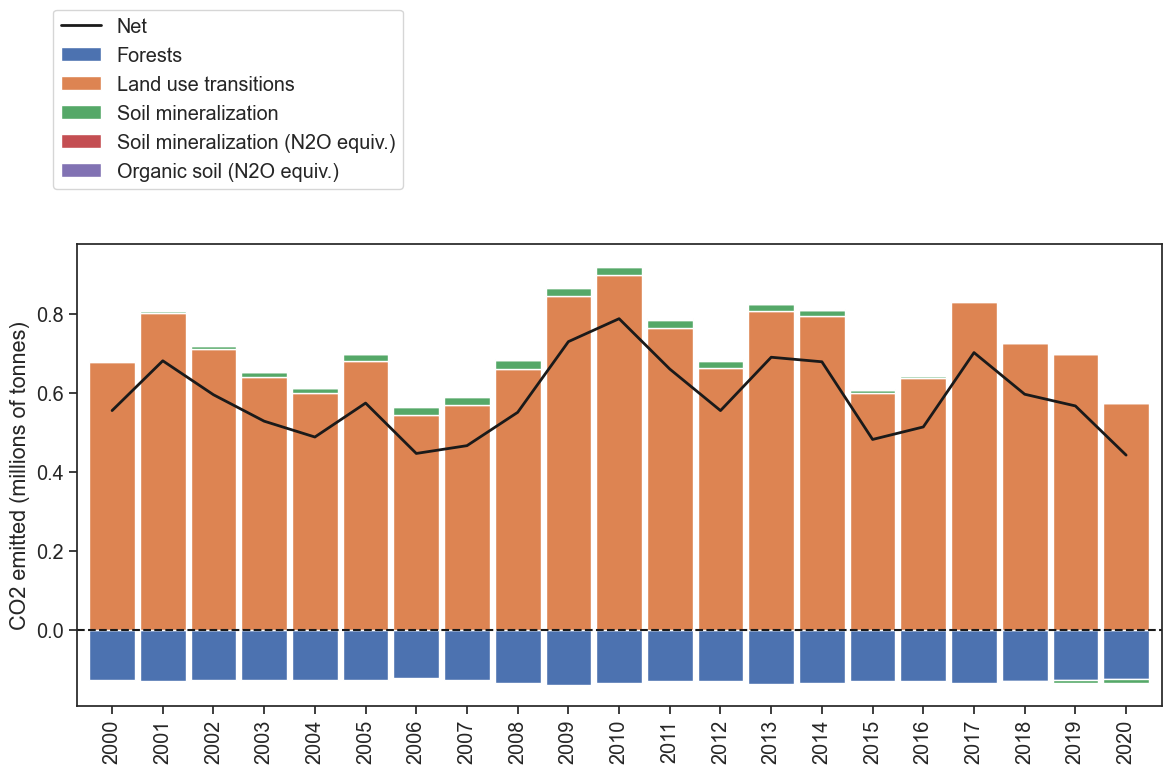

In [26]:
sns.set_theme(style="ticks", font_scale=1.3)

fig, ax = plt.subplots(figsize=(14, 6))
df_plot.plot.bar(stacked=True, ax=ax, width=0.9, legend=False)

if LANGUAGE == "en":
    label = "Net"
elif LANGUAGE == "es":
    label = "Neto"
else:
    raise ValueError("Language not supported")

df_plot.sum(axis=1).reset_index().assign(time_period=lambda df: df["time_period"].astype(str)).set_index("time_period")[0].plot(ax=ax, c="k", label=label, lw=2)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.axhline(0, 0, 1, c="k", ls="--")

ax.set_xlabel(None)

if LANGUAGE == "en":
    ax.set_ylabel("CO2 emitted (millions of tonnes)")
elif LANGUAGE == "es":
    ax.set_ylabel("CO2 emitido (millones de toneladas)")
else:
    raise ValueError("Language not supported")

ax.legend(bbox_to_anchor=(0.31, 1.53))
fig.savefig(figure_path / "carbon.jpg", bbox_inches="tight", dpi=200)

# Emissions by transition

In [81]:
def prettify_column(c: str, pretty_labels: bool) -> str:
    if c == "year":
        return c

    c = c.replace("emission_co2e_co2_lndu_conversion_", "")
    start, end = c.split("_to_")
    if pretty_labels:
        return f"{COLUMN_NAME_MAP[start]}-{COLUMN_NAME_MAP[end]}"
    else:
        return f"{start}-{end}"

In [82]:
df_transitions = (
    pd.read_csv(out_path / "small" / "transitions_emissions" / f"{ZONE}.csv")
    .drop(columns=["Unnamed: 0"])
    .assign(year=range(2000, 2036))
    .query("2000 <= year <= 2020")
    .assign(year=lambda df: df["year"].astype(str))
    .set_index("year")
)
df_transitions.columns = [prettify_column(c, pretty_labels=True) for c in df_transitions.columns]

0.0


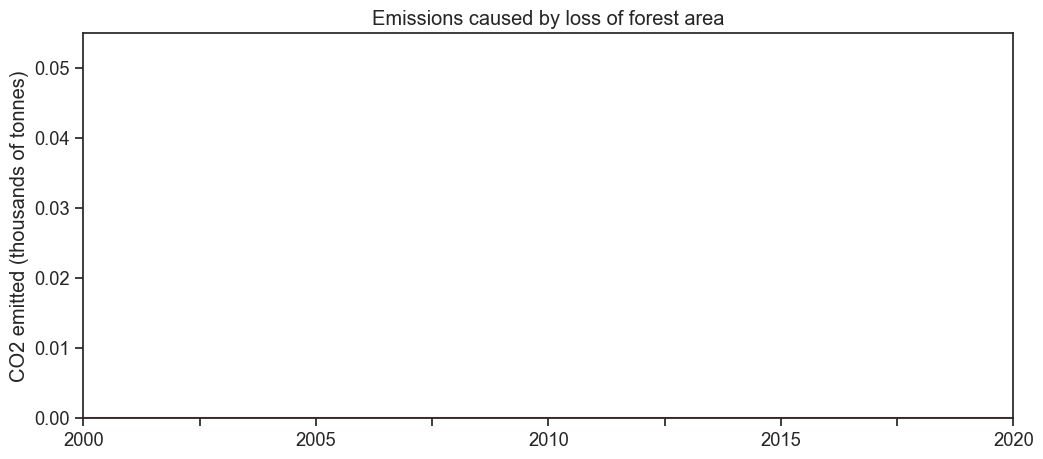

In [83]:
sns.set_theme(font_scale=1.2, style="ticks")

if LANGUAGE == "en":
    df_temp = df_transitions[[c for c in df_transitions.columns if c.startswith("Forests")]].sum(axis=1).multiply(1000)
elif LANGUAGE == "es":
    df_temp = df_transitions[[c for c in df_transitions.columns if c.startswith("Bosques")]].sum(axis=1).multiply(1000)
else:
    raise ValueError("Language not supported")

fig, ax = plt.subplots(figsize=(12, 5))
df_temp.plot(ax=ax, c="r")
print(df_temp.sum())

if LANGUAGE == "en":
    ax.set_title("Emissions caused by loss of forest area")
    ax.set_ylabel("CO2 emitted (thousands of tonnes)")
elif LANGUAGE == "es":
    ax.set_title("Emisiones causadas por la pérdida de área forestal")
    ax.set_ylabel("CO2 emitido (miles de toneladas)")
else:
    raise ValueError("Language not supported")

ax.set_xlabel(None)
ax.fill_between(df_temp.index, df_temp, alpha=0.3, color="red")

ax.set_xlim("2000", "2020")
ax.set_ylim(0, ax.get_ylim()[1])

fig.savefig(figure_path / "emissions_from_forest.jpg", bbox_inches="tight", dpi=200)

In [84]:
df_temp = (
    df_transitions
    .reset_index()
    .melt(id_vars="year")
    .assign(
        start=lambda df: df["variable"].str.split("-").str[0],
        end=lambda df: df["variable"].str.split("-").str[1]
    )
    .drop(columns="variable")
    .groupby(["year", "end"])
    ["value"]
    .sum()
    .reset_index()
    .pivot_table(index="year", columns="end", values="value")
)

if LANGUAGE == "en":
    df_temp = df_temp.filter(["Croplands", "Pastures", "Settlements"])
elif LANGUAGE == "es":
    df_temp = df_temp.filter(["Cultivos", "Pastizales p/ganado", "Asentamientos"])
else:
    raise ValueError("Language not supported")

TypeError: no numeric data to plot

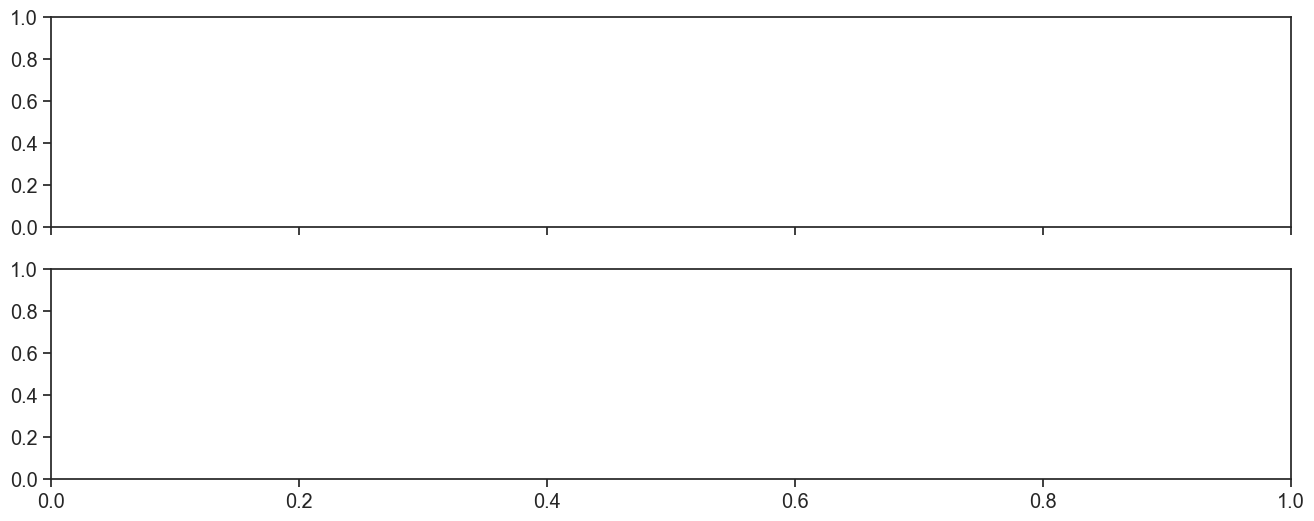

In [44]:
    sns.set_theme(font_scale=1.3, style="ticks")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

df_temp.plot(ax=ax1, legend=True, color=COLUMN_COLOR_MAP)
df_temp.sum(axis=1).plot(ax=ax1, c="k", lw="2", label="Total")

df_temp.plot.bar(ax=ax2, stacked=True, width=0.8, rot=0, color=COLUMN_COLOR_MAP)

ax1.set_ylim(*ax2.get_ylim())
ax1.set_xlabel(None)
ax1.xaxis.set_tick_params(labelbottom=True)
ax1.legend(bbox_to_anchor=(1, 0.76), loc="center left")

ax2.set_xlabel(None)
ax2.legend(bbox_to_anchor=(1, 0.82), loc="center left")

if LANGUAGE == "en":
    fig.supylabel("CO2 emitted (millions of tonnes)")
    fig.suptitle("Emissions by land use destination class", y=0.91)
elif LANGUAGE == "es":
    fig.supylabel("CO2 emitido (millones de toneladas)")
    fig.suptitle("Emisiones por clase de destino de uso de suelo", y=0.94)
else:
    raise ValueError("Language not supported")

fig.tight_layout()
fig.savefig(figure_path / "emissions_by_end.jpg", bbox_inches="tight", dpi=200)

2.4239895903909323


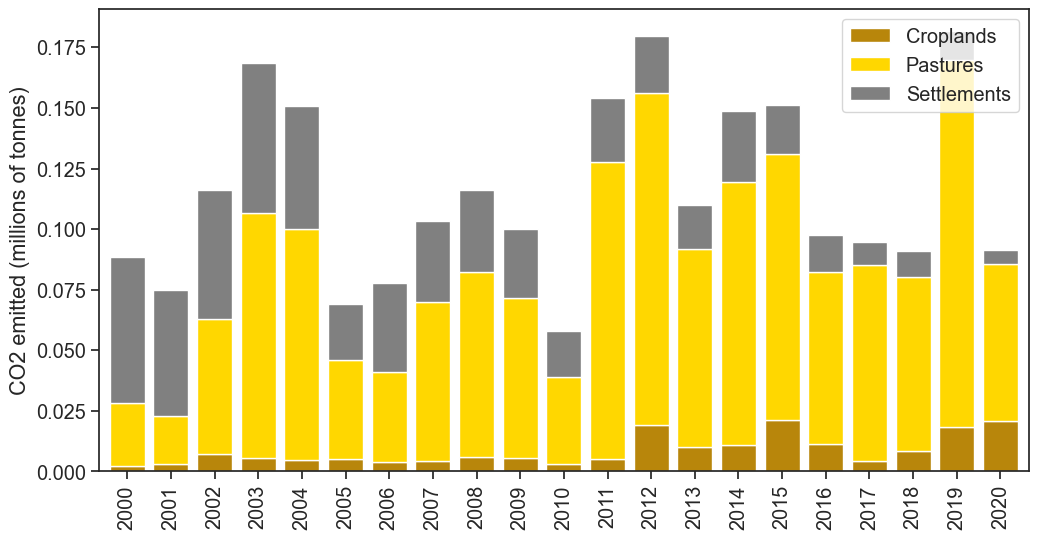

In [26]:
sns.set_theme(font_scale=1.3, style="ticks")

fig, ax = plt.subplots(figsize=(12, 6))
df_temp.plot.bar(ax=ax, stacked=True, width=0.8, rot=0, color=COLUMN_COLOR_MAP)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel(None)

print(df_temp.sum().sum())

if LANGUAGE == "en":
    ax.set_ylabel("CO2 emitted (millions of tonnes)")
elif LANGUAGE == "es":
    ax.set_ylabel("CO2 emitido (millones de toneladas)")
else:
    raise ValueError("Language not supported")

In [27]:
df_temp = (
    df_transitions
    .reset_index()
    .melt(id_vars="year")
    .assign(
        start=lambda df: df["variable"].str.split("-").str[0],
        end=lambda df: df["variable"].str.split("-").str[1]
    )
    .drop(columns="variable")
    .groupby(["year", "end"])
    ["value"]
    .sum()
    .reset_index()
    .pivot_table(index="year", columns="end", values="value")
    .multiply(1000)
)

if LANGUAGE == "en":
    df_temp = df_temp.filter(["Settlements"])
elif LANGUAGE == "es":
    df_temp = df_temp.filter(["Asentamientos"])
else:
    raise ValueError("Language not supported")

624.2326912675512


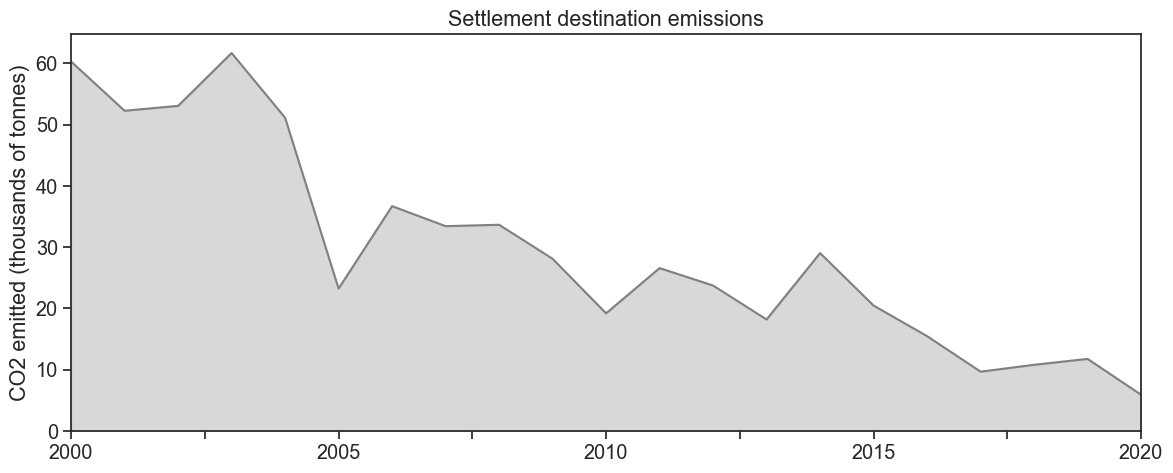

In [28]:
sns.set_theme(font_scale=1.3, style="ticks")

fig, ax = plt.subplots(figsize=(12, 5), sharex=True)

df_temp.plot(ax=ax, legend=False, color=COLUMN_COLOR_MAP)
print(df_temp.sum().item())

if LANGUAGE == "en":
    ax.fill_between(df_temp.index, df_temp.values.flatten(), alpha=0.3, color=COLUMN_COLOR_MAP["Settlements"])
    ax.set_ylabel("CO2 emitted (thousands of tonnes)")
    ax.set_title("Settlement destination emissions")
elif LANGUAGE == "es":
    ax.fill_between(df_temp.index, df_temp.values.flatten(), alpha=0.3, color=COLUMN_COLOR_MAP["Asentamientos"])
    ax.set_ylabel("CO2 emitido (miles de toneladas)")
    ax.set_title("Emisiones producidas por urbanización")
else:
    raise ValueError("Language not supported")

ax.set_xlabel(None)

ax.set_xlim("2000", "2020")
ax.set_ylim(0, ax.get_ylim()[1])

fig.tight_layout()
fig.savefig(figure_path / "emissions_by_urb.jpg", bbox_inches="tight", dpi=200)